# VAYU — Data Preparation Pipeline
## Step 3: Regression Dataset

**Prerequisite:** Run `vayu_step2_cleaning.ipynb` first — this notebook reads the master cleaned file.

---

### What This Step Builds

**Models that will use this data:** Linear Regression, Multiple Regression *(Lectures 8–17)*

**Target variable:** AQI — a single numeric value between 0 and 500  
**Features:** PM2.5, PM10, NO2, SO2, CO, O3 + time features (month, hour, day_of_week)

### What Linear Regression Requires from the Data

Linear regression is one of the most assumption-heavy models in ML. Before handing data to it, we need to verify four things:

1. **No missing values** — even a single NaN in a row causes the model to either crash or silently drop that row
2. **No extreme outliers** — a single extreme value can pull the regression line completely off course
3. **No multicollinearity** — if two features are highly correlated (e.g., PM2.5 and PM10 are both dust), the model cannot reliably assign credit to each one individually. Coefficients become unstable.
4. **Approximately normal feature distributions** — linear regression works best when features are not heavily skewed. A right-skewed feature can be log-transformed to improve this.

This notebook checks and fixes all four.

### Steps in This Notebook
1. Load master cleaned file
2. Compute AQI (target variable) from pollutants using CPCB formula
3. Select features and drop NaN rows
4. Visualize feature distributions + check skewness
5. Apply log transformation to right-skewed features
6. Check multicollinearity (correlation matrix + VIF)
7. Outlier detection and capping (Winsorization)
8. Train/test split stratified by city
9. Save regression datasets

In [15]:
!pip install statsmodels


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.labelsize']    = 11
sns.set_palette('muted')

pd.set_option('display.max_columns', 40)

OUTPUT_DIR = './data/cleaned/01_regression'
SHARED_DIR = './data/cleaned/04_shared'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


---
## Section 1 — Load Master Cleaned File

We read from `05_shared/` — the output of Step 2. If parquet is available it loads in seconds. If not, it falls back to CSV automatically.

In [17]:
parquet_path = os.path.join(SHARED_DIR, 'master_cleaned.parquet')
csv_path     = os.path.join(SHARED_DIR, 'master_cleaned.csv')

if os.path.exists(parquet_path):
    df = pd.read_parquet(parquet_path)
    print(f'Loaded from parquet: {parquet_path}')
else:
    df = pd.read_csv(csv_path, low_memory=False)
    print(f'Loaded from CSV: {csv_path}')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Loaded from CSV: ./data/cleaned/05_shared/master_cleaned.csv
Shape: 842,160 rows x 35 columns
Columns: ['city', 'state', 'latitude', 'longitude', 'datetime', 'month', 'day_name', 'is_weekend', 'season', 'time_of_day', 'humidity_percent', 'dew_point_c', 'wind_gusts_kmh', 'precipitation_mm', 'is_raining', 'heavy_rain', 'pressure_msl_hpa', 'cloud_cover_percent', 'pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'dust_ugm3', 'aod', 'us_aqi', 'aqi_category', 'pm25_category_india', 'festival_period', 'crop_burning_season', 'year', 'day', 'hour', 'day_of_week']


---
## Section 2 — Compute AQI (Target Variable)

### Why Do We Need to Compute AQI?

The primary dataset (`aqi_india_38cols_knn_final.csv`) does not have a pre-computed numeric AQI column — it has the individual pollutant concentrations and an `aqi_category` column. For **regression**, we need the **numeric AQI value** (0–500) as our target.

We compute it using the official CPCB sub-index formula:

```
Sub-index = ((I_high - I_low) / (C_high - C_low)) × (C - C_low) + I_low
```

Where C is the measured concentration and the breakpoints are CPCB's official health thresholds. The final AQI is the **maximum sub-index** across all available pollutants — the pollutant that is most dangerous that day drives the overall AQI.

This is exactly how the CPCB dashboard computes AQI in real time.

In [18]:
# ── Auto-detect pollutant columns ──────────────────────────────────────────
POLLUTANT_KEYWORDS = ['pm2', 'pm10', 'no2', 'so2', 'co_', 'o3', 'ozone', 'nh3']
EXCLUDE_KEYWORDS   = ['cloud', 'cover', 'humidity', 'temp', 'pressure',
                      'wind', 'rain', 'solar', 'visibility', 'dew', 'uv']

pollutant_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if any(k in c.lower() for k in POLLUTANT_KEYWORDS)
    and not any(ex in c.lower() for ex in EXCLUDE_KEYWORDS)
]

city_col = next((c for c in df.columns if c.lower() in ['city', 'city_name']), None)
date_col = next((c for c in df.columns
                 if 'datetime' in c.lower() or c.lower() == 'date'), None)
cat_col  = next((c for c in df.columns
                 if 'category' in c.lower() or 'bucket' in c.lower()), None)

print(f'Pollutant cols : {pollutant_cols}')
print(f'City col       : {city_col}')
print(f'Date col       : {date_col}')
print(f'Category col   : {cat_col}')

Pollutant cols : ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3']
City col       : city
Date col       : datetime
Category col   : aqi_category


In [19]:
# ── CPCB Sub-index formula ─────────────────────────────────────────────────
def sub_index(val, breakpoints):
    """Compute AQI sub-index for one pollutant using CPCB breakpoints."""
    if pd.isna(val) or val < 0:
        return np.nan
    for C_lo, C_hi, I_lo, I_hi in breakpoints:
        if C_lo <= val <= C_hi:
            return round(((I_hi - I_lo) / (C_hi - C_lo)) * (val - C_lo) + I_lo, 1)
    return np.nan

# CPCB official breakpoints per pollutant
BP_PM25  = [(0,30,0,50),(30,60,51,100),(60,90,101,200),
            (90,120,201,300),(120,250,301,400),(250,500,401,500)]
BP_PM10  = [(0,50,0,50),(50,100,51,100),(100,250,101,200),
            (250,350,201,300),(350,430,301,400),(430,600,401,500)]
BP_NO2   = [(0,40,0,50),(40,80,51,100),(80,180,101,200),
            (180,280,201,300),(280,400,301,400),(400,800,401,500)]
BP_SO2   = [(0,40,0,50),(40,80,51,100),(80,380,101,200),
            (380,800,201,300),(800,1600,301,400),(1600,2100,401,500)]
BP_CO_MG = [(0,1,0,50),(1,2,51,100),(2,10,101,200),     # mg/m3
            (10,17,201,300),(17,34,301,400),(34,50,401,500)]
BP_CO_UG = [(0,1000,0,50),(1000,2000,51,100),(2000,10000,101,200),  # ug/m3
            (10000,17000,201,300),(17000,34000,301,400),(34000,50000,401,500)]
BP_O3    = [(0,50,0,50),(50,100,51,100),(100,168,101,200),
            (168,208,201,300),(208,748,301,400),(748,1000,401,500)]

def compute_aqi_row(row):
    """Compute AQI for one row — max of all available pollutant sub-indices."""
    subs = []
    for col in pollutant_cols:
        cl  = col.lower()
        val = pd.to_numeric(row.get(col, np.nan), errors='coerce')
        if   'pm2' in cl and 'pm10' not in cl: subs.append(sub_index(val, BP_PM25))
        elif 'pm10' in cl:                     subs.append(sub_index(val, BP_PM10))
        elif 'no2'  in cl:                     subs.append(sub_index(val, BP_NO2))
        elif 'so2'  in cl:                     subs.append(sub_index(val, BP_SO2))
        elif 'co'   in cl:
            bp = BP_CO_UG if ('ugm3' in cl or 'ug_m3' in cl) else BP_CO_MG
            subs.append(sub_index(val, bp))
        elif 'o3' in cl or 'ozone' in cl:      subs.append(sub_index(val, BP_O3))
    valid = [s for s in subs if not pd.isna(s)]
    return max(valid) if valid else np.nan

# Check if AQI already exists in the data
aqi_col = next((c for c in df.columns if c.lower() in ['aqi', 'air_quality_index']), None)

if aqi_col:
    print(f'AQI column already exists: "{aqi_col}" — skipping computation')
    df['AQI'] = pd.to_numeric(df[aqi_col], errors='coerce')
    aqi_col   = 'AQI'
else:
    print('No AQI column found — computing from pollutants using CPCB formula...')
    print('This may take ~30 seconds for 842k rows...')
    df['AQI'] = df.apply(compute_aqi_row, axis=1)
    aqi_col   = 'AQI'
    print('Done.')

aqi_vals = df['AQI'].dropna()
print(f'\nAQI computed: {aqi_vals.notna().sum():,} valid values')
print(f'  Min   : {aqi_vals.min():.1f}')
print(f'  Max   : {aqi_vals.max():.1f}')
print(f'  Mean  : {aqi_vals.mean():.1f}')
print(f'  Median: {aqi_vals.median():.1f}')

No AQI column found — computing from pollutants using CPCB formula...
This may take ~30 seconds for 842k rows...
Done.

AQI computed: 842,160 valid values
  Min   : 8.6
  Max   : 387.6
  Mean  : 109.5
  Median: 88.7


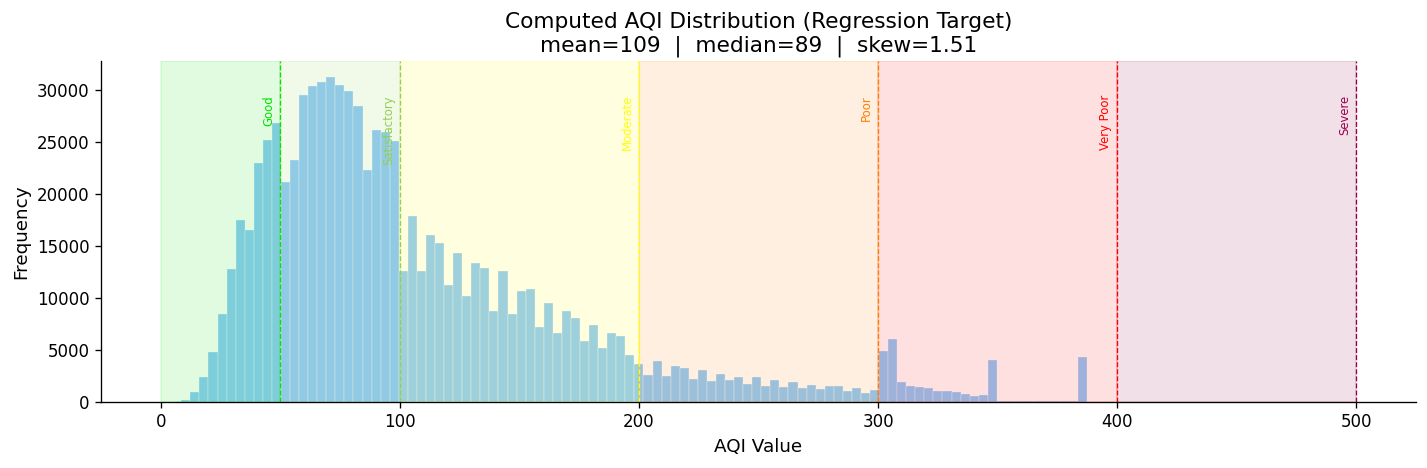

In [20]:
# ── Visualize computed AQI distribution with CPCB bands ───────────────────
band_edges  = [0, 50, 100, 200, 300, 400, 500]
band_colors = ['#00E400','#92D050','#FFFF00','#FF7E00','#FF0000','#99004C']
band_labels = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']

aqi_plot = aqi_vals[(aqi_vals >= 0) & (aqi_vals <= 500)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(aqi_plot, bins=100, color='#90CAF9', edgecolor='white', linewidth=0.2)

for lo, hi, cb in zip(band_edges[:-1], band_edges[1:], band_colors):
    ax.axvspan(lo, hi, alpha=0.12, color=cb)
for edge, label, cb in zip(band_edges[1:], band_labels, band_colors):
    ax.axvline(edge, color=cb, linewidth=0.8, linestyle='--')
    ax.text(edge - 2, ax.get_ylim()[1] * 0.9, label,
            rotation=90, fontsize=7, color=cb, va='top', ha='right')

ax.set_xlabel('AQI Value')
ax.set_ylabel('Frequency')
ax.set_title(
    f'Computed AQI Distribution (Regression Target)\n'
    f'mean={aqi_plot.mean():.0f}  |  median={aqi_plot.median():.0f}  |  '
    f'skew={aqi_plot.skew():.2f}'
)
plt.tight_layout()
plt.show()

---
## Section 3 — Feature Selection

### Which Columns Do We Include and Why?

**Included features:**

| Feature | Why Included |
|---|---|
| PM2.5 | Strongest predictor of AQI in India. Dominant pollutant in northern cities. |
| PM10 | Second strongest. Independent signal from road and construction dust. |
| NO2 | Vehicle and industrial emissions. Key predictor in metro cities. |
| SO2 | Coal burning. Less weight in metros, more in industrial zones. |
| CO | Combustion indicator. Correlated with traffic density. |
| O3 | Ground-level ozone. Inversely correlated with other pollutants in some seasons. |
| month | Captures seasonality — winter months are systematically more polluted. |
| hour | Captures diurnal pattern — rush hour peaks at 8AM and 6PM. |
| day_of_week | Captures weekly cycle — weekends have lower industrial activity. |

**Excluded features:**

| Feature | Why Excluded |
|---|---|
| city (raw text) | Cannot use text in linear regression. Needs encoding. Kept simple here. |
| AQI_category | Derived from AQI — including it would be data leakage (target info in features). |
| year | Would cause the model to extrapolate by year. Not useful for prediction. |
| day | Too granular — noise without meaning for regression. |

In [21]:
# Define final feature set for regression
TIME_FEATURES = ['month', 'hour', 'day_of_week']

# Only keep time features that exist in the dataframe
time_feats_present = [f for f in TIME_FEATURES if f in df.columns]

ALL_FEATURES = pollutant_cols + time_feats_present
TARGET       = 'AQI'

print(f'Pollutant features : {pollutant_cols}')
print(f'Time features      : {time_feats_present}')
print(f'Total features     : {len(ALL_FEATURES)}')
print(f'Target             : {TARGET}')

# Subset to only the columns we need
keep_cols = ALL_FEATURES + [TARGET]
if city_col:
    keep_cols = [city_col] + keep_cols
if date_col:
    keep_cols = [date_col] + keep_cols

keep_cols = list(dict.fromkeys(keep_cols))  # deduplicate, preserve order
df_reg    = df[keep_cols].copy()

print(f'\nRows before dropping NaN : {len(df_reg):,}')
print('Missing values per column:')
missing = df_reg[ALL_FEATURES + [TARGET]].isnull().sum()
missing = missing[missing > 0]
if len(missing):
    print(missing.to_string())
else:
    print('  None — all features and target are complete')

# Drop rows with any NaN in features or target
df_reg = df_reg.dropna(subset=ALL_FEATURES + [TARGET]).reset_index(drop=True)
print(f'Rows after  dropping NaN : {len(df_reg):,}')

Pollutant features : ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3']
Time features      : ['month', 'hour', 'day_of_week']
Total features     : 9
Target             : AQI

Rows before dropping NaN : 842,160
Missing values per column:
  None — all features and target are complete
Rows after  dropping NaN : 842,160


---
## Section 4 — Feature Distribution + Skewness Check

### Why Skewness Matters for Linear Regression

Linear regression assumes that the **residuals** (prediction errors) are normally distributed. While this does not strictly require the features to be normal, heavily right-skewed features often produce non-normal residuals in practice.

**Rule of thumb:**
- Skewness between -1 and 1 → acceptable, no transformation needed
- Skewness > 2 or < -2 → apply `log1p` transformation (log of value + 1, handles zeros)

PM2.5, PM10, and CO tend to be heavily right-skewed in Indian data because most readings are moderate but a few extreme pollution events create a very long right tail.

Skewness per pollutant feature:
(> 2 or < -2 = transformation recommended)
--------------------------------------------------
  so2_ugm3                              3.328  <- LOG TRANSFORM
  co_ugm3                               3.300  <- LOG TRANSFORM
  pm10_ugm3                             3.188  <- LOG TRANSFORM
  no2_ugm3                              2.611  <- LOG TRANSFORM
  pm2_5_ugm3                            2.088  <- LOG TRANSFORM
  o3_ugm3                               0.716


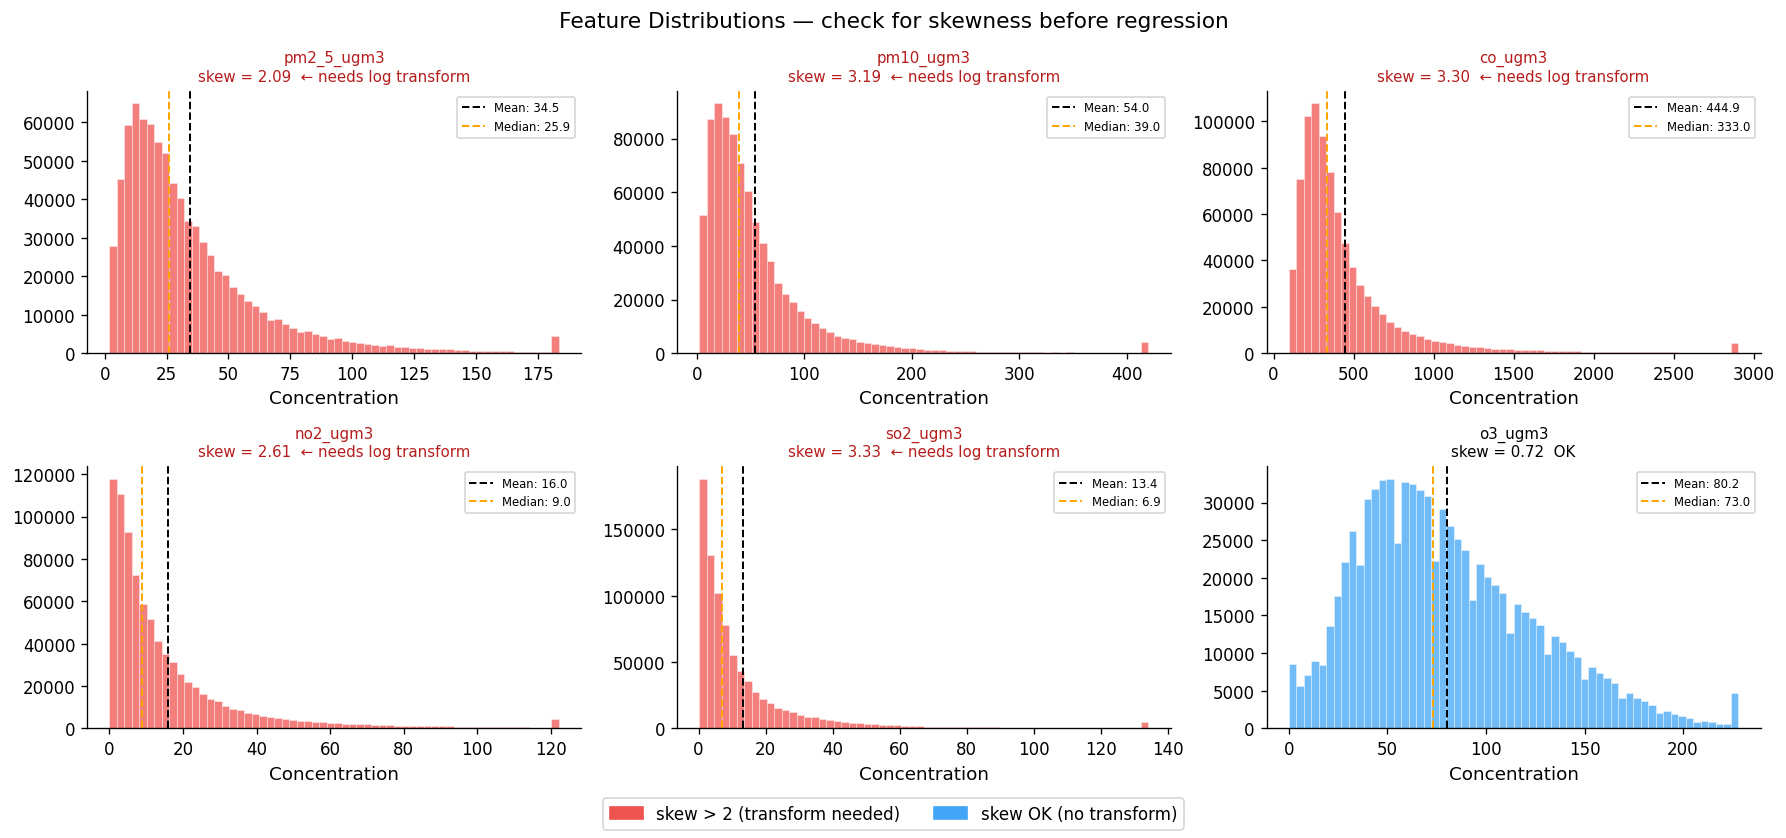

In [22]:
skew_vals = df_reg[pollutant_cols].skew().sort_values(ascending=False)

print('Skewness per pollutant feature:')
print('(> 2 or < -2 = transformation recommended)')
print('-' * 50)
for col, skew in skew_vals.items():
    flag = '  <- LOG TRANSFORM' if abs(skew) > 2 else ''
    print(f'  {col:<35} {skew:>7.3f}{flag}')

# ── Distribution grid ──────────────────────────────────────────────────────
n     = len(pollutant_cols)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)

for i, col in enumerate(pollutant_cols):
    ax   = axes[i // ncols][i % ncols]
    vals = df_reg[col].dropna()
    skew = vals.skew()

    color = '#EF5350' if abs(skew) > 2 else '#42A5F5'
    ax.hist(vals, bins=60, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(vals.mean(),   color='black',  linestyle='--', linewidth=1.2, label=f'Mean: {vals.mean():.1f}')
    ax.axvline(vals.median(), color='orange', linestyle='--', linewidth=1.2, label=f'Median: {vals.median():.1f}')
    ax.set_title(f'{col}\nskew = {skew:.2f}  {"← needs log transform" if abs(skew)>2 else "OK"}',
                 fontsize=9, color='#B71C1C' if abs(skew) > 2 else 'black')
    ax.set_xlabel('Concentration')
    ax.legend(fontsize=7)

for j in range(i + 1, nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

red_p  = mpatches.Patch(color='#EF5350', label='skew > 2 (transform needed)')
blue_p = mpatches.Patch(color='#42A5F5', label='skew OK (no transform)')
fig.legend(handles=[red_p, blue_p], loc='lower center', ncol=2, fontsize=10)

plt.suptitle('Feature Distributions — check for skewness before regression', fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

---
## Section 5 — Log Transformation for Skewed Features

### Why `log1p` and Not `log`?

We use `np.log1p(x)` which computes `log(x + 1)` instead of `log(x)`. This handles the case where some values are exactly zero — `log(0)` is undefined (negative infinity), but `log(1) = 0` which is perfectly valid.

We keep the **original columns intact** and create new `_log` columns. This way:
- You can compare model performance with and without transformation
- Tree-based models in Step 4 can use the raw columns (they don't need normal distributions)
- The log columns are used for Linear Regression specifically

  pm2_5_ugm3                          skew   2.088 ->  -0.127  (log1p applied)
  pm10_ugm3                           skew   3.188 ->  -0.113  (log1p applied)
  co_ugm3                             skew   3.300 ->   0.662  (log1p applied)
  no2_ugm3                            skew   2.611 ->   0.108  (log1p applied)
  so2_ugm3                            skew   3.328 ->   0.272  (log1p applied)


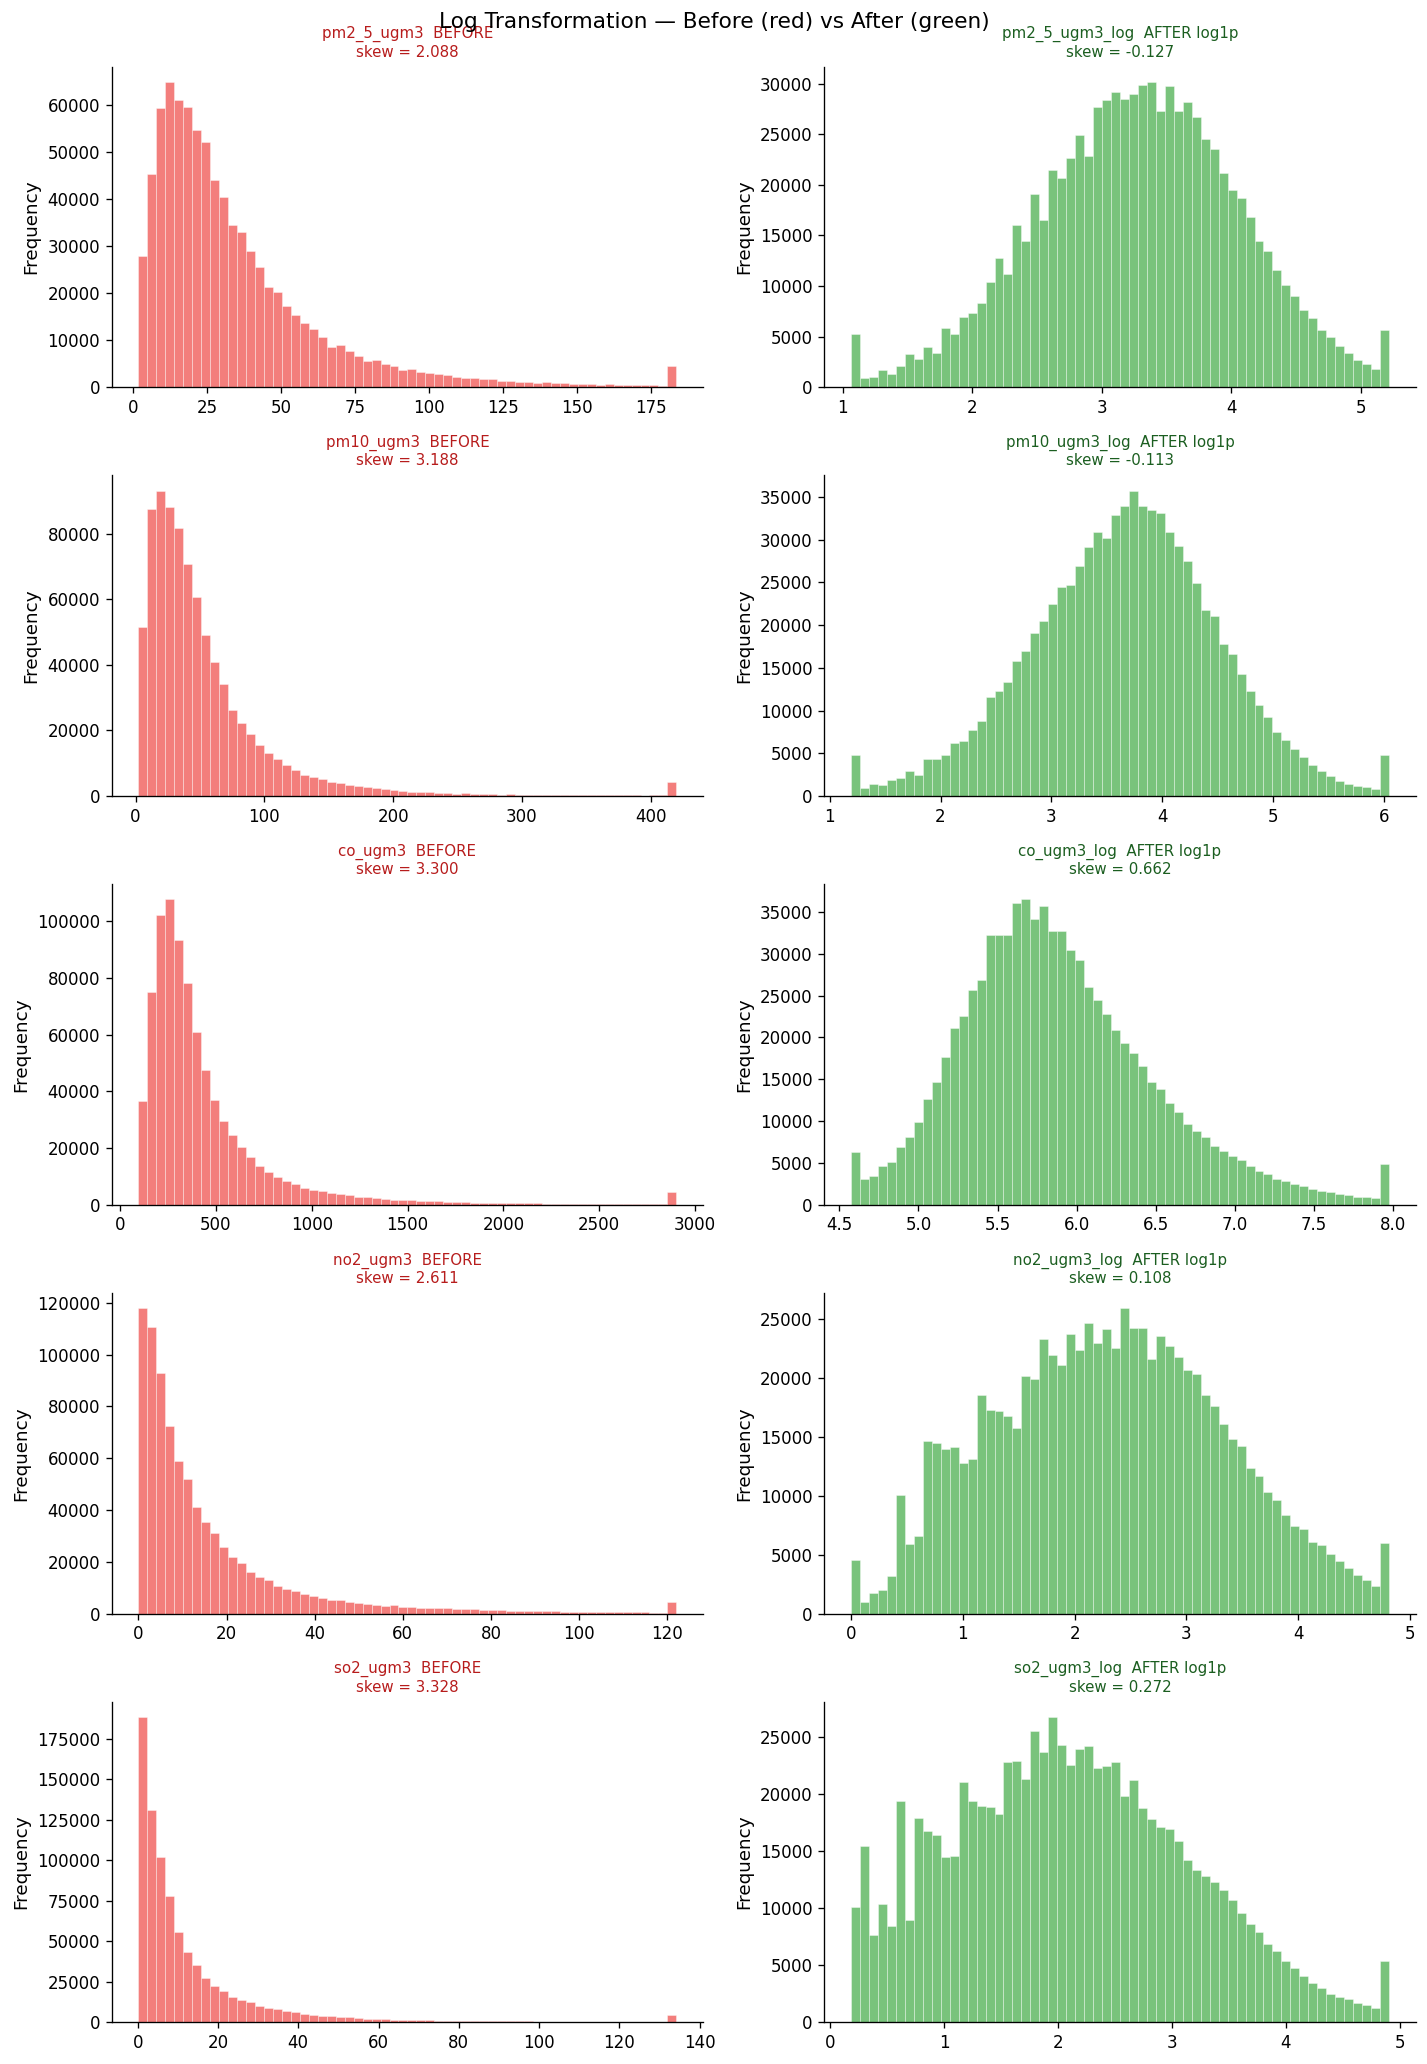


Final features for regression model: ['pm2_5_ugm3_log', 'pm10_ugm3_log', 'co_ugm3_log', 'no2_ugm3_log', 'so2_ugm3_log', 'o3_ugm3', 'month', 'hour', 'day_of_week']


In [23]:
SKEW_THRESHOLD = 2.0
log_transformed = []

for col in pollutant_cols:
    skew = df_reg[col].skew()
    if abs(skew) > SKEW_THRESHOLD:
        new_col = col + '_log'
        df_reg[new_col] = np.log1p(df_reg[col].clip(lower=0))
        log_transformed.append((col, new_col, skew, df_reg[new_col].skew()))
        print(f'  {col:<35} skew {skew:>7.3f} -> {df_reg[new_col].skew():>7.3f}  (log1p applied)')

if not log_transformed:
    print('No features exceeded skew threshold — no log transformation applied.')

# ── Before/After skewness comparison ──────────────────────────────────────
if log_transformed:
    n_trans = len(log_transformed)
    fig, axes = plt.subplots(n_trans, 2,
                             figsize=(12, 3.5 * n_trans),
                             squeeze=False)

    for i, (orig, logged, skew_before, skew_after) in enumerate(log_transformed):
        axes[i][0].hist(df_reg[orig].dropna(),   bins=60, color='#EF5350',
                        alpha=0.75, edgecolor='white', linewidth=0.3)
        axes[i][0].set_title(f'{orig}  BEFORE\nskew = {skew_before:.3f}',
                              fontsize=9, color='#B71C1C')

        axes[i][1].hist(df_reg[logged].dropna(),  bins=60, color='#4CAF50',
                        alpha=0.75, edgecolor='white', linewidth=0.3)
        axes[i][1].set_title(f'{logged}  AFTER log1p\nskew = {skew_after:.3f}',
                              fontsize=9, color='#1B5E20')

        for ax in axes[i]:
            ax.set_ylabel('Frequency')

    plt.suptitle('Log Transformation — Before (red) vs After (green)', fontsize=13)
    plt.tight_layout()
    plt.show()

# Final feature list — use log version where available
log_col_map   = {orig: logged for orig, logged, _, _ in log_transformed}
FINAL_FEATURES = [
    log_col_map.get(c, c) for c in pollutant_cols
] + time_feats_present

print(f'\nFinal features for regression model: {FINAL_FEATURES}')

---
## Section 6 — Multicollinearity Check

### What Is Multicollinearity and Why Does It Break Linear Regression?

Multicollinearity occurs when two or more features are highly correlated with each other. For example, PM2.5 and PM10 both measure particulate matter — on days when PM2.5 is high, PM10 is usually also high.

When two features are nearly identical, linear regression cannot figure out which one to assign the coefficient to. It tries to distribute the credit and both coefficients become unstable and meaningless. The model still makes predictions, but the coefficients can no longer be interpreted as "how much does PM2.5 affect AQI holding everything else constant?"

**Two ways to detect multicollinearity:**
1. **Pearson correlation matrix** — quick, pairwise. If `|r| > 0.85`, the two features are highly collinear.
2. **VIF (Variance Inflation Factor)** — more thorough. Measures how much each feature can be predicted by ALL other features combined. VIF > 5 is a concern, VIF > 10 means the feature should be dropped or merged.

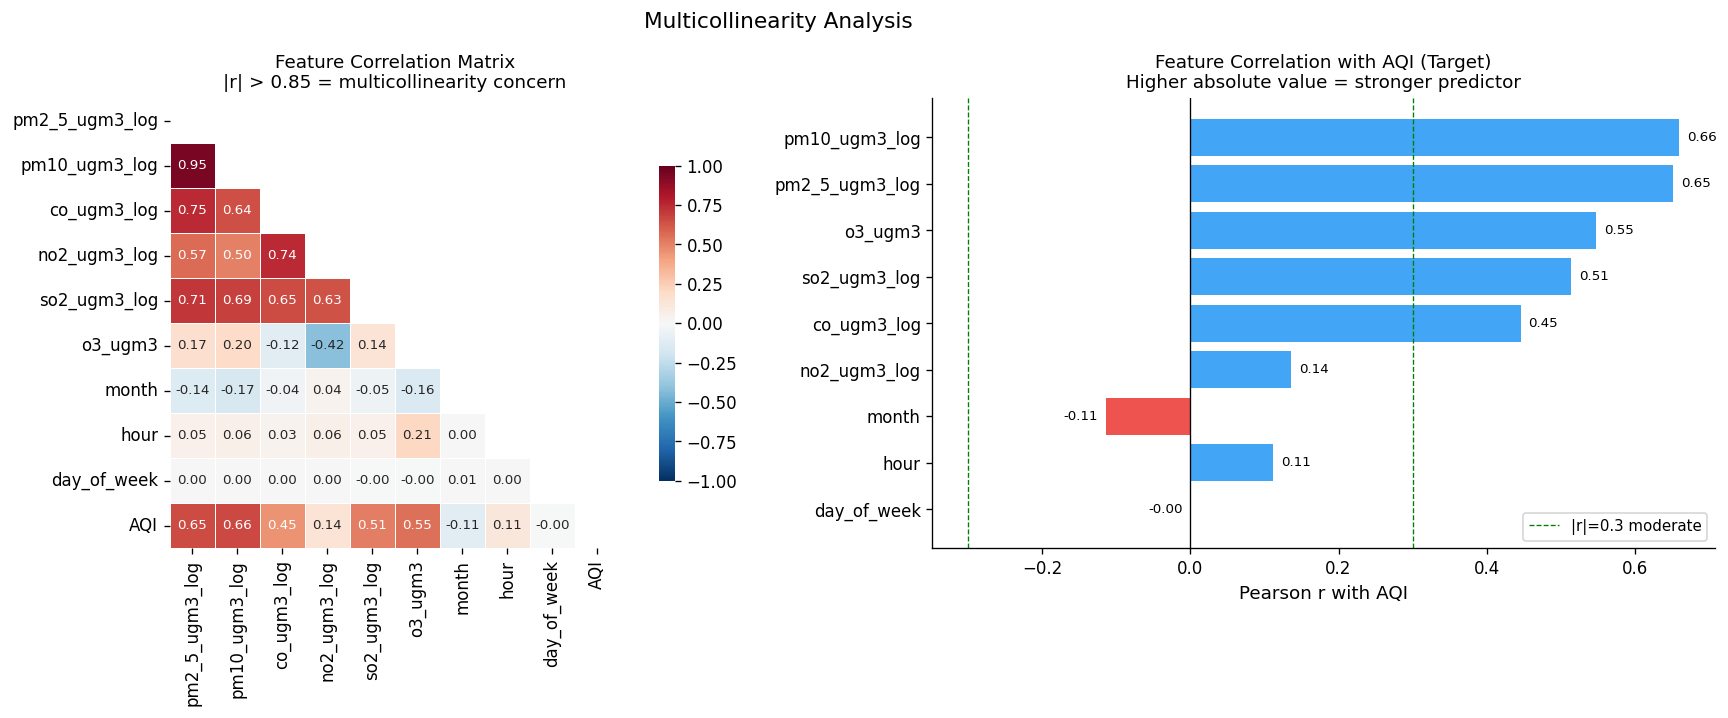

High intercorrelations (|r| > 0.85) between features:
  pm2_5_ugm3_log  <->  pm10_ugm3_log  :  r = 0.949  <- consider dropping one


In [24]:
# Use only numeric features for correlation
numeric_features = [c for c in FINAL_FEATURES if c in df_reg.columns
                    and df_reg[c].dtype in [np.float64, np.int64, float, int]]

corr_mat = df_reg[numeric_features + [TARGET]].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: full correlation heatmap
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=axes[0],
    cbar_kws={'shrink': 0.7}, annot_kws={'size': 8}
)
axes[0].set_title('Feature Correlation Matrix\n|r| > 0.85 = multicollinearity concern', fontsize=11)

# Right: feature-vs-target bar chart
feature_target_corr = corr_mat[TARGET].drop(TARGET).sort_values(key=abs, ascending=True)
colors = ['#EF5350' if v < 0 else '#42A5F5' for v in feature_target_corr.values]
axes[1].barh(feature_target_corr.index, feature_target_corr.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline( 0.3, color='green',  linestyle='--', linewidth=0.8, label='|r|=0.3 moderate')
axes[1].axvline(-0.3, color='green',  linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Pearson r with AQI')
axes[1].set_title('Feature Correlation with AQI (Target)\nHigher absolute value = stronger predictor', fontsize=11)
axes[1].legend(fontsize=9)
for i, (val, name) in enumerate(zip(feature_target_corr.values, feature_target_corr.index)):
    axes[1].text(val + (0.01 if val >= 0 else -0.01), i,
                 f'{val:.2f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=8)

plt.suptitle('Multicollinearity Analysis', fontsize=13)
plt.tight_layout()
plt.show()

# Flag high intercorrelations
print('High intercorrelations (|r| > 0.85) between features:')
found_any = False
for i, c1 in enumerate(numeric_features):
    for c2 in numeric_features[i+1:]:
        r = corr_mat.loc[c1, c2]
        if abs(r) > 0.85:
            print(f'  {c1}  <->  {c2}  :  r = {r:.3f}  <- consider dropping one')
            found_any = True
if not found_any:
    print('  None — no multicollinearity issues detected')

VIF Scores (Variance Inflation Factor):
  VIF < 5  : acceptable
  VIF 5-10 : moderate concern
  VIF > 10 : high multicollinearity — consider dropping

  pm2_5_ugm3_log                      VIF =  230.76  <- HIGH
  pm10_ugm3_log                       VIF =  196.26  <- HIGH
  co_ugm3_log                         VIF =   62.14  <- HIGH
  no2_ugm3_log                        VIF =   24.94  <- HIGH
  so2_ugm3_log                        VIF =   14.51  <- HIGH
  o3_ugm3                             VIF =    9.31  <- moderate
  month                               VIF =    5.00
  hour                                VIF =    4.17
  day_of_week                         VIF =    3.22


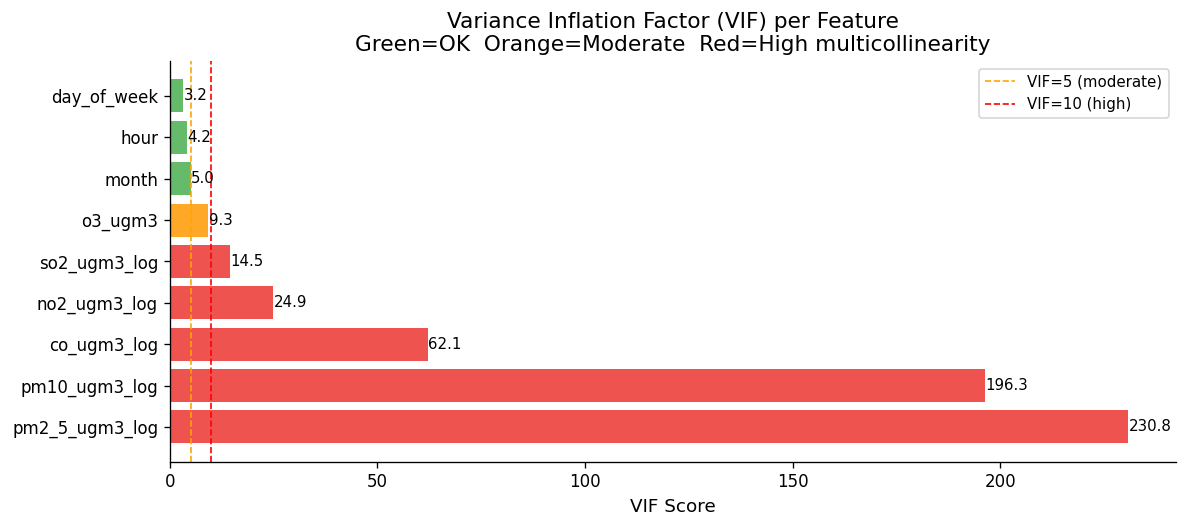

In [25]:
# ── VIF Calculation ────────────────────────────────────────────────────────
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    vif_df_input = df_reg[numeric_features].dropna()
    vif_data     = pd.DataFrame()
    vif_data['feature'] = numeric_features
    vif_data['VIF']     = [
        round(variance_inflation_factor(vif_df_input.values, i), 2)
        for i in range(len(numeric_features))
    ]
    vif_data = vif_data.sort_values('VIF', ascending=False)

    print('VIF Scores (Variance Inflation Factor):')
    print('  VIF < 5  : acceptable')
    print('  VIF 5-10 : moderate concern')
    print('  VIF > 10 : high multicollinearity — consider dropping')
    print()
    for _, row in vif_data.iterrows():
        flag = '  <- HIGH' if row['VIF'] > 10 else '  <- moderate' if row['VIF'] > 5 else ''
        print(f'  {row["feature"]:<35} VIF = {row["VIF"]:>7.2f}{flag}')

    fig, ax = plt.subplots(figsize=(10, max(4, len(numeric_features) * 0.5)))
    colors  = ['#EF5350' if v > 10 else '#FFA726' if v > 5 else '#66BB6A'
               for v in vif_data['VIF']]
    bars    = ax.barh(vif_data['feature'], vif_data['VIF'], color=colors)
    ax.axvline(5,  color='orange', linestyle='--', linewidth=1, label='VIF=5 (moderate)')
    ax.axvline(10, color='red',    linestyle='--', linewidth=1, label='VIF=10 (high)')
    ax.set_xlabel('VIF Score')
    ax.set_title('Variance Inflation Factor (VIF) per Feature\nGreen=OK  Orange=Moderate  Red=High multicollinearity')
    ax.legend(fontsize=9)
    for bar, val in zip(bars, vif_data['VIF']):
        ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

except ImportError:
    print('statsmodels not installed — skipping VIF calculation.')
    print('Install with: pip install statsmodels')
    print('VIF is optional — correlation matrix above is sufficient for Eval 1.')

---
## Section 7 — Outlier Detection and Capping (Winsorization)

### Why Cap Outliers Instead of Dropping Them?

After cleaning sentinel values and validating physical ranges, some extreme but real readings may still exist — e.g., a genuine pollution spike during a crop burning event. Two options:

1. **Trimming (drop the row)** — removes the outlier entirely. Causes data loss and can bias the training set.
2. **Capping / Winsorization** — replaces values beyond the 99th percentile with the 99th percentile value. The data point is kept but its extreme influence is limited.

We use capping because:
- We lose no rows
- The model still sees that extreme events exist, just not how extreme
- Linear regression is particularly sensitive to outliers since a single extreme point can drag the regression line toward it

We only cap the **target (AQI)** and **features** — not timestamps or city names.

Winsorization at 99th percentile:


,column,cap_value,capped_rows
0,pm2_5_ugm3_log,5.05,8384
1,pm10_ugm3_log,5.68,8402
2,co_ugm3_log,7.70,8421
3,no2_ugm3_log,4.65,8414
4,so2_ugm3_log,4.65,8405
5,o3_ugm3,206.00,8202
6,AQI,348.60,8387


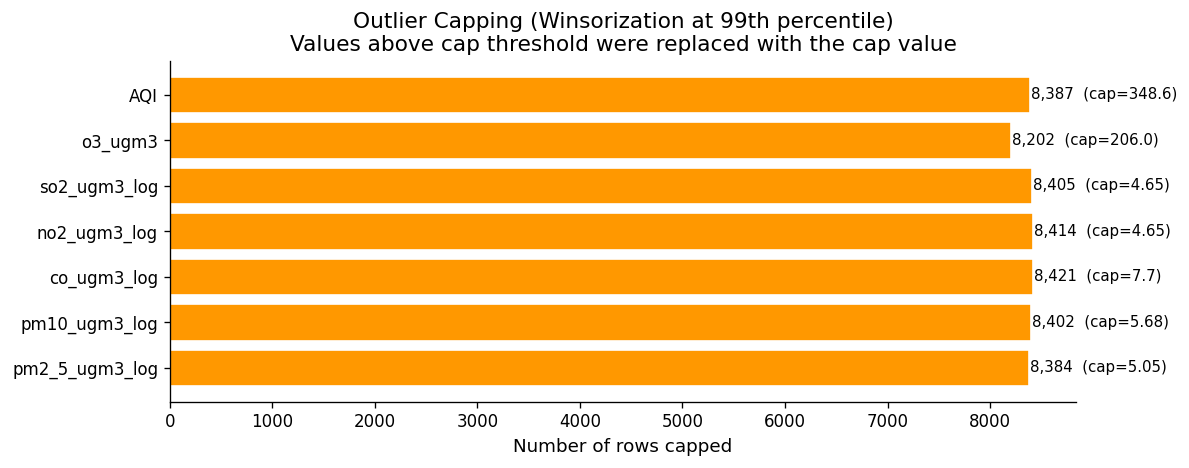

In [26]:
CAP_PERCENTILE = 99  # cap values above the 99th percentile
cols_to_cap    = numeric_features + [TARGET]
cap_summary    = []

for col in cols_to_cap:
    if col not in df_reg.columns:
        continue
    vals     = df_reg[col].dropna()
    p99      = vals.quantile(CAP_PERCENTILE / 100)
    outliers = (df_reg[col] > p99).sum()

    if outliers > 0:
        df_reg[col] = df_reg[col].clip(upper=p99)
        cap_summary.append({'column': col, 'cap_value': round(p99, 2), 'capped_rows': outliers})

if cap_summary:
    cap_df = pd.DataFrame(cap_summary)
    print(f'Winsorization at {CAP_PERCENTILE}th percentile:')
    display(cap_df)

    # Boxplots before/after style — show capped vs uncapped using quantile info
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(
        cap_df['column'],
        cap_df['capped_rows'],
        color='#FF9800', edgecolor='white'
    )
    ax.set_xlabel('Number of rows capped')
    ax.set_title(f'Outlier Capping (Winsorization at {CAP_PERCENTILE}th percentile)\n'
                 f'Values above cap threshold were replaced with the cap value')
    for i, row in cap_df.iterrows():
        ax.text(row['capped_rows'] + 10, i,
                f'{row["capped_rows"]:,}  (cap={row["cap_value"]})',
                va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print(f'No values above the {CAP_PERCENTILE}th percentile — no capping needed.')

---
## Section 8 — Train/Test Split

### Why Stratify by City?

A naive random 80/20 split might accidentally put most of Delhi's rows in training and most of Mumbai's in test. The model would learn Delhi's pollution patterns thoroughly but be tested mostly on Mumbai — an unfair evaluation.

By stratifying on city, we guarantee that every city is proportionally represented in both train and test sets. The model is evaluated on a mix of cities it has seen patterns from, making the evaluation more reliable.

**Split ratio: 80% train / 20% test** — standard for this dataset size. With 800k+ rows, 20% still gives 160k+ test rows which is more than enough for reliable evaluation.

Train set :  673,728 rows  (80.0%)
Test set  :  168,432 rows  (20.0%)
Features  : 9
Target    : AQI


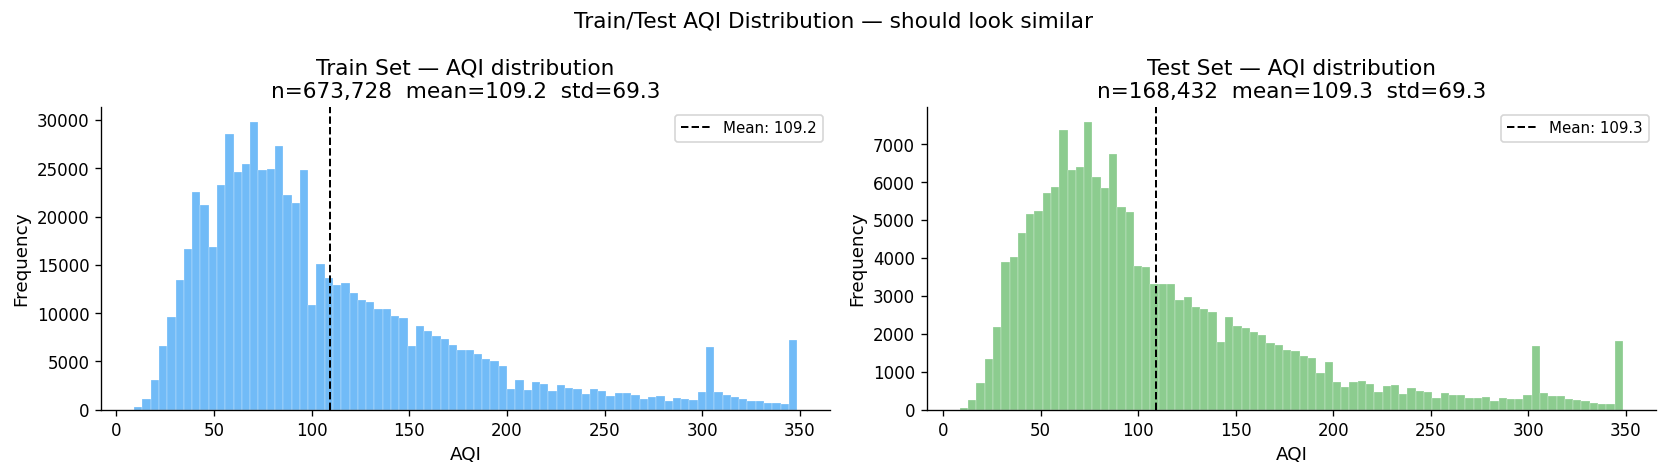

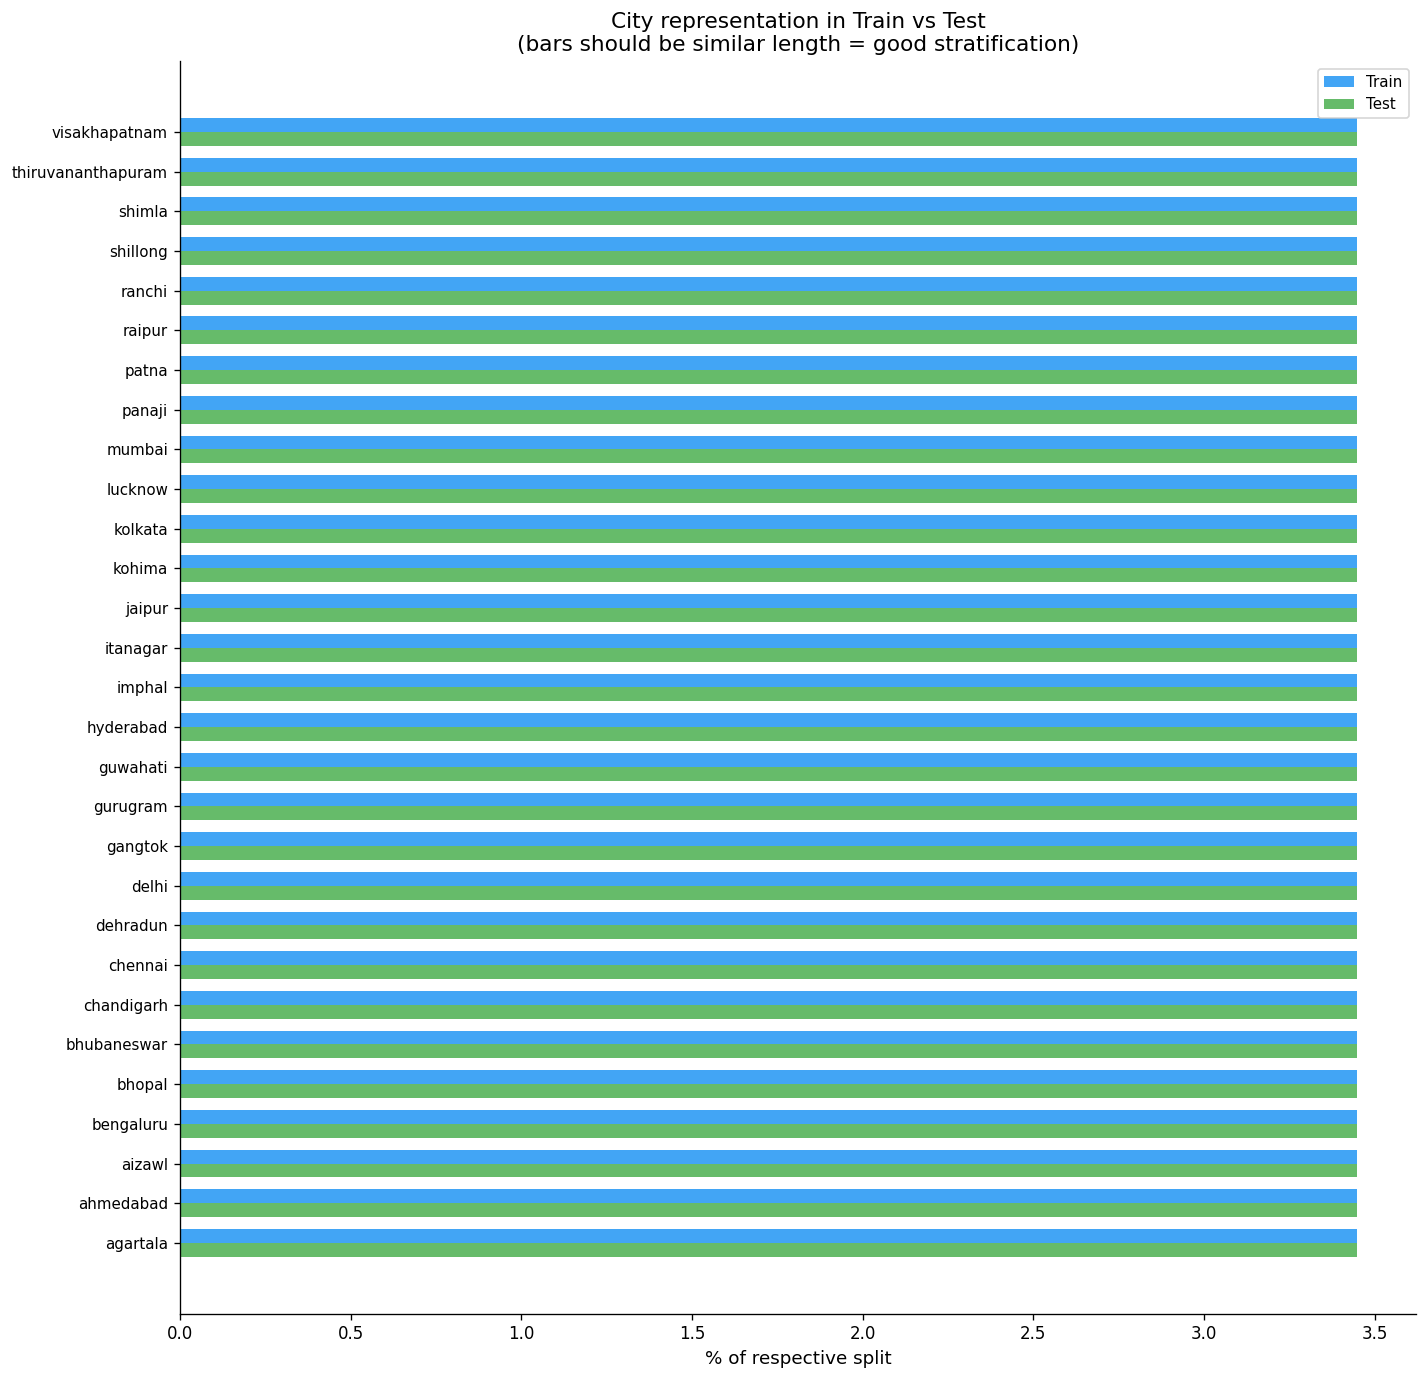

In [27]:
X = df_reg[FINAL_FEATURES]
y = df_reg[TARGET]

# Stratify by city if available
stratify_col = df_reg[city_col] if city_col and city_col in df_reg.columns else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col
)

print(f'Train set : {len(X_train):>8,} rows  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test set  : {len(X_test):>8,} rows  ({len(X_test)/len(X)*100:.1f}%)')
print(f'Features  : {X_train.shape[1]}')
print(f'Target    : {TARGET}')

# ── Visualize train/test AQI distributions ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, y_split, label, color in [
    (axes[0], y_train, 'Train Set', '#42A5F5'),
    (axes[1], y_test,  'Test Set',  '#66BB6A'),
]:
    ax.hist(y_split, bins=80, color=color, alpha=0.75, edgecolor='white', linewidth=0.2)
    ax.axvline(y_split.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {y_split.mean():.1f}')
    ax.set_xlabel('AQI')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{label} — AQI distribution\nn={len(y_split):,}  mean={y_split.mean():.1f}  std={y_split.std():.1f}')
    ax.legend(fontsize=9)

plt.suptitle('Train/Test AQI Distribution — should look similar', fontsize=13)
plt.tight_layout()
plt.show()

# ── City distribution in train vs test ────────────────────────────────────
if city_col:
    train_city = df_reg.loc[X_train.index, city_col].value_counts(normalize=True)
    test_city  = df_reg.loc[X_test.index,  city_col].value_counts(normalize=True)

    city_comp  = pd.DataFrame({'Train %': train_city * 100,
                               'Test %' : test_city  * 100}).dropna()

    fig, ax = plt.subplots(figsize=(12, max(5, len(city_comp) * 0.4)))
    x = np.arange(len(city_comp))
    w = 0.35
    ax.barh(x + w/2, city_comp['Train %'], w, color='#42A5F5', label='Train')
    ax.barh(x - w/2, city_comp['Test %'],  w, color='#66BB6A', label='Test')
    ax.set_yticks(x)
    ax.set_yticklabels(city_comp.index, fontsize=9)
    ax.set_xlabel('% of respective split')
    ax.set_title('City representation in Train vs Test\n(bars should be similar length = good stratification)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

---
## Section 9 — Save Regression Datasets

In [28]:
# Combine X and y back into single dataframes for saving
train_df = X_train.copy()
train_df[TARGET] = y_train.values
if city_col and city_col in df_reg.columns:
    train_df.insert(0, city_col, df_reg.loc[X_train.index, city_col].values)

test_df  = X_test.copy()
test_df[TARGET]  = y_test.values
if city_col and city_col in df_reg.columns:
    test_df.insert(0, city_col, df_reg.loc[X_test.index, city_col].values)

TRAIN_PATH   = os.path.join(OUTPUT_DIR, 'regression_train.csv')
TEST_PATH    = os.path.join(OUTPUT_DIR, 'regression_test.csv')
FEATURE_PATH = os.path.join(OUTPUT_DIR, 'feature_list.txt')

train_df.to_csv(TRAIN_PATH, index=False)
test_df.to_csv(TEST_PATH,   index=False)

with open(FEATURE_PATH, 'w') as f:
    f.write('VAYU — Regression Feature List\n')
    f.write('=' * 50 + '\n\n')
    f.write(f'Target: {TARGET}\n\n')
    f.write('Features:\n')
    for feat in FINAL_FEATURES:
        orig = next((o for o, l, _, _ in log_transformed if l == feat), feat)
        note = '  (log1p transformed)' if feat != orig else ''
        f.write(f'  {feat}{note}\n')
    f.write(f'\nTrain rows : {len(train_df):,}\n')
    f.write(f'Test rows  : {len(test_df):,}\n')

print('SAVED:')
print(f'  {TRAIN_PATH:<55} {os.path.getsize(TRAIN_PATH)/1024**2:.1f} MB')
print(f'  {TEST_PATH:<55} {os.path.getsize(TEST_PATH)/1024**2:.1f} MB')
print(f'  {FEATURE_PATH}')
print()
print('=' * 60)
print('  STEP 3 COMPLETE')
print('=' * 60)
print(f'  Features          : {FINAL_FEATURES}')
print(f'  Target            : {TARGET}')
print(f'  Train rows        : {len(train_df):,}')
print(f'  Test rows         : {len(test_df):,}')
print(f'  Log-transformed   : {[l for _, l, _, _ in log_transformed] if log_transformed else "None"}')
print()
print('  TO TRAIN A MODEL:')
print('  from sklearn.linear_model import LinearRegression')
print('  train = pd.read_csv("data/cleaned/01_regression/regression_train.csv")')
print('  X_train = train[feature_list]')
print('  y_train = train["AQI"]')
print('  model   = LinearRegression().fit(X_train, y_train)')
print('=' * 60)

SAVED:
  ./data/cleaned/01_regression/regression_train.csv       77.3 MB
  ./data/cleaned/01_regression/regression_test.csv        19.3 MB
  ./data/cleaned/01_regression/feature_list.txt

  STEP 3 COMPLETE
  Features          : ['pm2_5_ugm3_log', 'pm10_ugm3_log', 'co_ugm3_log', 'no2_ugm3_log', 'so2_ugm3_log', 'o3_ugm3', 'month', 'hour', 'day_of_week']
  Target            : AQI
  Train rows        : 673,728
  Test rows         : 168,432
  Log-transformed   : ['pm2_5_ugm3_log', 'pm10_ugm3_log', 'co_ugm3_log', 'no2_ugm3_log', 'so2_ugm3_log']

  TO TRAIN A MODEL:
  from sklearn.linear_model import LinearRegression
  train = pd.read_csv("data/cleaned/01_regression/regression_train.csv")
  X_train = train[feature_list]
  y_train = train["AQI"]
  model   = LinearRegression().fit(X_train, y_train)
